# Week 7 Activity: Pandas Practice and Binomial Classification

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

In this activity, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' to classify rock vs classical music.

In [202]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

plt.style.use('default')

### Filter dataset

First, read the csv into a dataframe. Then, create a new dataframe that only includes rock and pop samples.

In [203]:
raw_data = pd.read_csv('../Datasets/features_30_sec.csv')

genres = ['pop', 'rock']
data = raw_data[raw_data['label'].isin(genres)]

data.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
700,pop.00000.wav,661504,0.389631,0.090863,0.185917,0.007513,3421.887738,1.080267e+06,3409.775605,163694.297157,...,112.463516,2.514723,92.615662,4.111930,113.117233,9.181066,87.627289,4.741255,88.584061,pop
701,pop.00001.wav,661504,0.412993,0.097699,0.262579,0.014924,3702.105111,1.404155e+06,3431.856264,179373.095619,...,129.778473,5.566532,205.448044,3.822952,170.974274,5.576165,166.527878,4.927082,155.335678,pop
702,pop.00002.wav,661504,0.417771,0.093556,0.215172,0.006579,3214.086840,1.006318e+06,3269.678966,107054.369743,...,94.625061,1.415107,72.024689,2.811311,58.061012,-1.410339,44.048363,-3.386550,46.421040,pop
703,pop.00003.wav,661504,0.409812,0.081134,0.129422,0.001808,1836.956691,7.874765e+05,2066.669705,408916.095988,...,68.658119,4.753404,77.756416,-3.510077,71.796509,4.904540,61.578075,-3.211654,61.053921,pop
704,pop.00004.wav,661504,0.384296,0.083575,0.211175,0.002561,2753.120791,7.178949e+05,2861.501507,149359.339153,...,47.624577,-1.329443,36.215866,-0.874240,43.780357,0.691995,53.095066,-1.774849,48.859238,pop


### Explore the data

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You should at a minimum create a bar graph and a box plot and compute the correlation between a few features (especially those you plan to select).

Outside of variability in the data, think about why certain features may help us differentiate the two categories based on musical reasoning. 

In [204]:
data.isnull().sum()

filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8_mean                 0
mfcc8_var     

In [205]:
data.columns

Index(['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
  

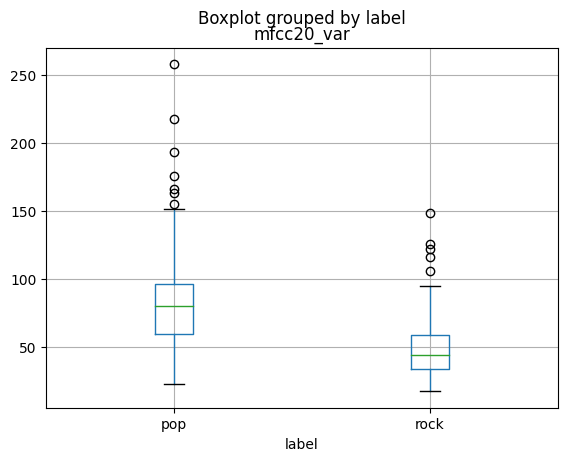

In [206]:
# went through this with all columns, keeping any that seemed significant

fig, ax = plt.subplots()
data.boxplot(column='mfcc20_var', by='label', ax=ax)

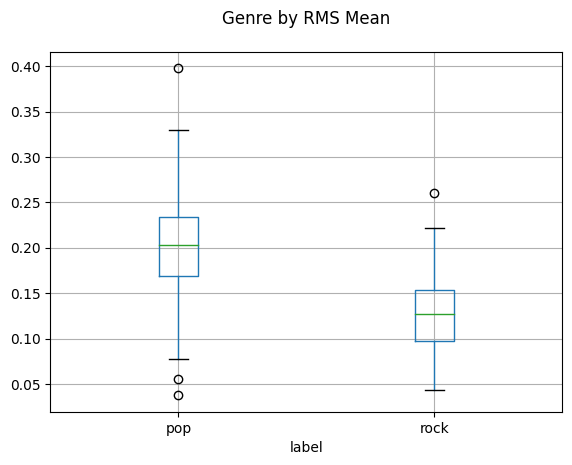

In [207]:
fig, ax = plt.subplots()
data.boxplot(column='rms_mean', by='label', ax=ax)
fig.suptitle("")
ax.set_title('Genre by RMS Mean', pad=20)

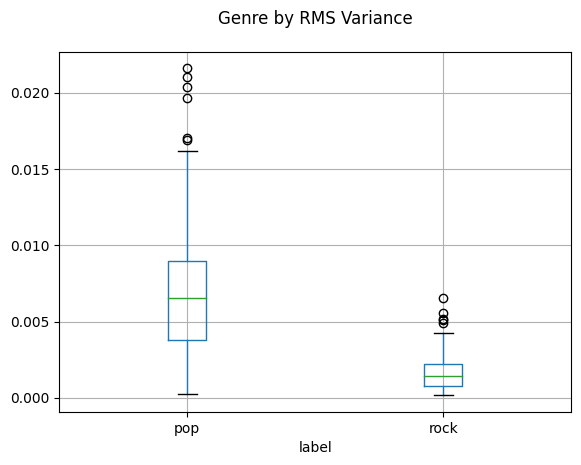

In [208]:
fig, ax = plt.subplots()
data.boxplot(column='rms_var', by='label', ax=ax)
fig.suptitle("")
ax.set_title('Genre by RMS Variance', pad=20)

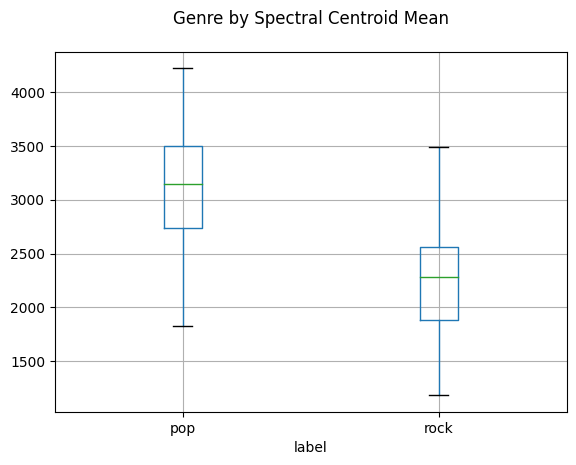

In [209]:
fig, ax = plt.subplots()
data.boxplot(column='spectral_centroid_mean', by='label', ax=ax)
fig.suptitle("")
ax.set_title('Genre by Spectral Centroid Mean', pad=20)

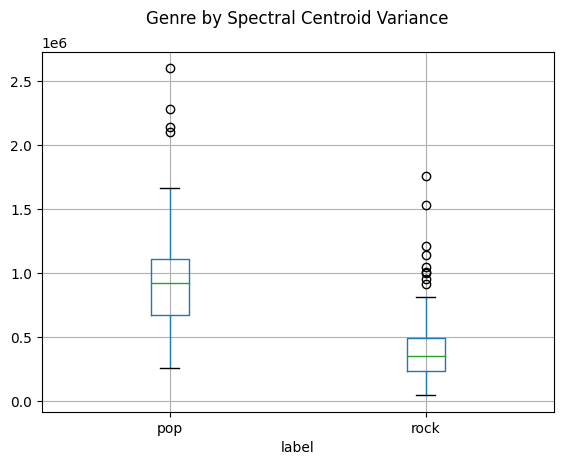

In [210]:
fig, ax = plt.subplots()
data.boxplot(column='spectral_centroid_var', by='label', ax=ax)
fig.suptitle("")
ax.set_title('Genre by Spectral Centroid Variance', pad=20)

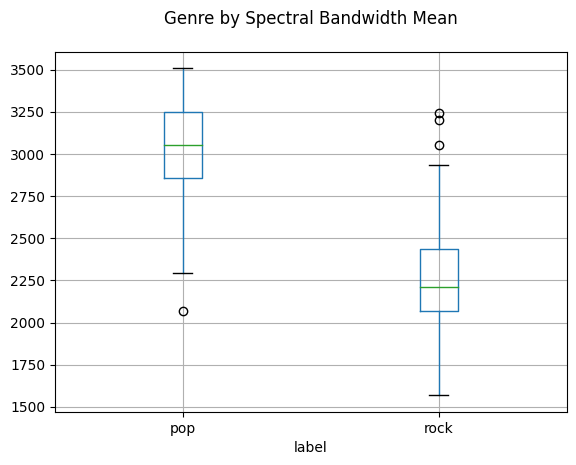

In [211]:
fig, ax = plt.subplots()
data.boxplot(column='spectral_bandwidth_mean', by='label', ax=ax)
fig.suptitle("")
ax.set_title('Genre by Spectral Bandwidth Mean', pad=20)

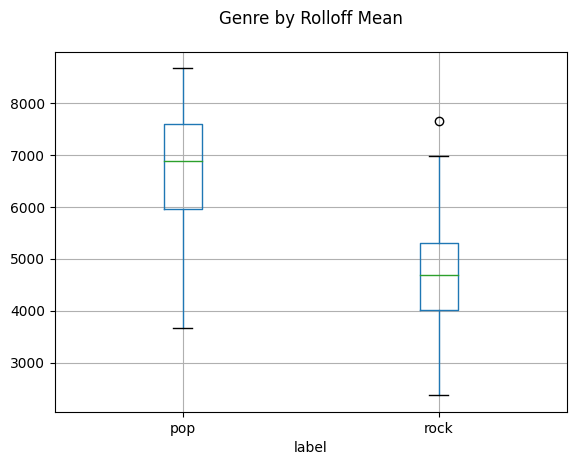

In [212]:
fig, ax = plt.subplots()
data.boxplot(column='rolloff_mean', by='label', ax=ax)
fig.suptitle("")
ax.set_title('Genre by Rolloff Mean', pad=20)

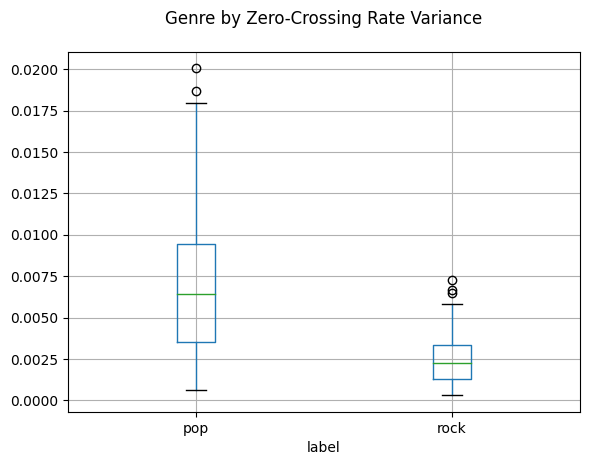

In [213]:
fig, ax = plt.subplots()
data.boxplot(column='zero_crossing_rate_var', by='label', ax=ax)
fig.suptitle("")
ax.set_title('Genre by Zero-Crossing Rate Variance', pad=20)

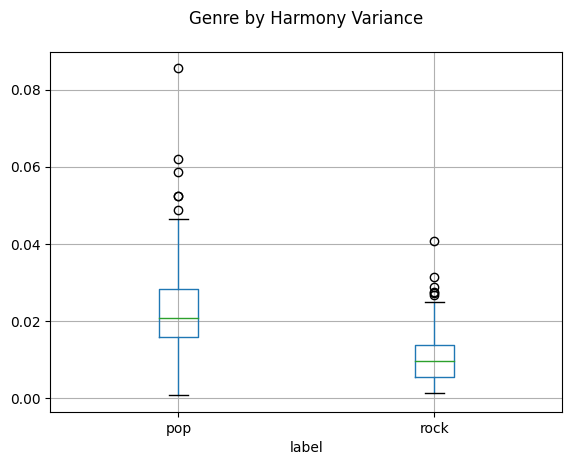

In [214]:
fig, ax = plt.subplots()
data.boxplot(column='harmony_var', by='label', ax=ax)
fig.suptitle("")
ax.set_title('Genre by Harmony Variance', pad=20)

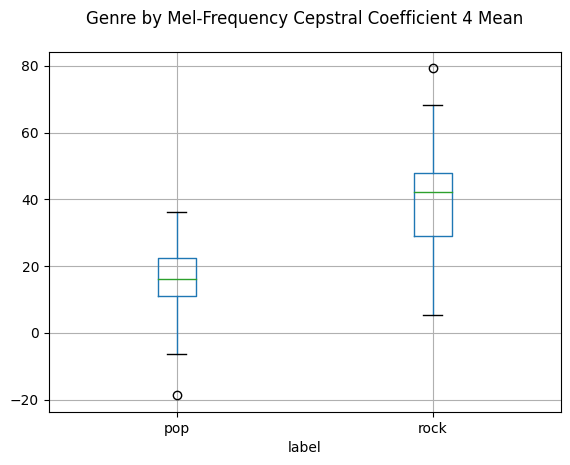

In [215]:
fig, ax = plt.subplots()
data.boxplot(column='mfcc4_mean', by='label', ax=ax)
fig.suptitle("")
ax.set_title('Genre by Mel-Frequency Cepstral Coefficient 4 Mean', pad=20)

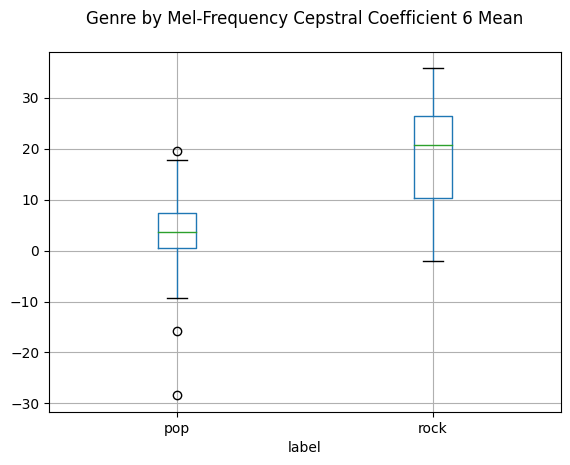

In [216]:
fig, ax = plt.subplots()
data.boxplot(column='mfcc6_mean', by='label', ax=ax)
fig.suptitle("")
ax.set_title('Genre by Mel-Frequency Cepstral Coefficient 6 Mean', pad=20)

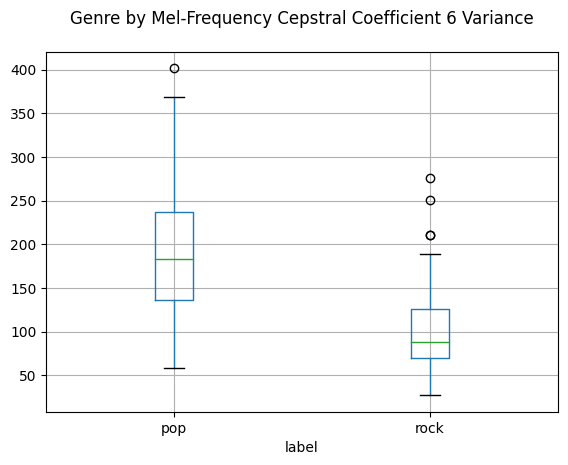

In [217]:
fig, ax = plt.subplots()
data.boxplot(column='mfcc6_var', by='label', ax=ax)
fig.suptitle("")
ax.set_title('Genre by Mel-Frequency Cepstral Coefficient 6 Variance', pad=20)

In [218]:
# I wanted to do a binomial test on these distributions to get some sense of how correlated each was, in order to
# pick just 5 features out of these 11, so I looked up how to do that.

narrowed_features = ['rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'rolloff_mean', 'zero_crossing_rate_var', 'mfcc4_mean', 'mfcc6_mean', 'mfcc6_var']

pop = data[data['label'] == 'pop']
rock = data[data['label'] == 'rock']

p = []

for feature in narrowed_features:
    stat, p_value = ttest_ind(pop[feature], rock[feature])
    p.append(p_value)

analysis = pd.DataFrame({'feature': narrowed_features, 'p_value': p})
analysis.sort_values(by=['p_value'], ascending=True, inplace=True)
analysis

,feature,p_value
4,spectral_bandwidth_mean,4.852313e-37
7,mfcc4_mean,7.098057e-29
8,mfcc6_mean,5.376075e-28
5,rolloff_mean,9.931918e-27
1,rms_var,1.090218e-22
2,spectral_centroid_mean,3.330791e-22
9,mfcc6_var,1.712561e-21
3,spectral_centroid_var,3.324163e-20
6,zero_crossing_rate_var,2.637941e-19
0,rms_mean,3.251946e-19


### Define your feature matrix

Set your x and y based on your selected features and the label outcome.
Note: you will need to convert your 'label' column to 0 and 1. You can do so manually or with .get_dummies

In [219]:
# ok so now we know that the 5 features with the lowest p-value out of the ones i selected are as follows
selected_features = analysis['feature'][:5]

labels = pd.get_dummies(data['label'], drop_first=True)
data_narrow = data[selected_features]
data_dmy = pd.concat([data_narrow,labels],axis=1)
data_dmy

,spectral_bandwidth_mean,mfcc4_mean,mfcc6_mean,rolloff_mean,rms_var,rock
700,3409.775605,27.055033,1.185324,7952.938014,0.007513,0
701,3431.856264,15.692759,1.682378,8072.977711,0.014924,0
702,3269.678966,16.929377,10.805136,7424.433605,0.006579,0
703,2066.669705,36.250137,-1.198539,3670.803274,0.001808,0
704,2861.501507,16.362434,-0.563406,5986.680118,0.002561,0
...,...,...,...,...,...,...
995,2106.541053,59.050125,19.726795,4253.557033,0.000345,1
996,2068.942009,49.117840,22.882061,4149.338328,0.000588,1
997,1927.293153,52.814674,21.742352,4031.405321,0.000322,1
998,1818.450280,56.605164,20.622280,3015.631004,0.001211,1


### Scale your feature matrix

Use StandardScaler to scale your feature matrix.

What would happen if you didn't scale?

In [220]:
scaler = StandardScaler()
scaler.fit(data_dmy)

data_norm = scaler.transform(data_dmy)
data_norm

array([[ 1.5531673 , -0.03915107, -0.90352624,  1.53072767,  0.66987424,
        -1.        ],
       [ 1.59746085, -0.72080739, -0.85886336,  1.61093334,  2.31692983,
        -1.        ],
       [ 1.27213505, -0.64661903, -0.03913495,  1.17760242,  0.46241431,
        -1.        ],
       ...,
       [-1.42067551,  1.50624578,  0.94363214, -1.08948171, -0.928163  ,
         1.        ],
       [-1.63901307,  1.7336484 ,  0.84298776, -1.76818099, -0.7306661 ,
         1.        ],
       [-1.68161472,  1.51374901,  1.20409618, -1.61365044, -0.92515341,
         1.        ]])

### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. For this activity, use 30% test size.

In [221]:
categories = data_norm[:,5]
predictors = data_norm[:,:5]

pred_train, pred_test, cat_train, cat_test = train_test_split(predictors, categories, test_size=0.3, random_state=25)

### Train the Model

Train the model using logistic regression.

Take a look at your model's coefficients. What do they tell you about each feature's contribution to the model?

In [222]:
model = LogisticRegression(solver='lbfgs')
model.fit(pred_train, cat_train)
predictions = model.predict(pred_test)

### Evaluate

Calculate the confusion matrix (and view as a data frame).

What does the matrix tell you? What error type occurs most often?

In [223]:
# the confusion matrix describes predicted vs actual classifications
# the more common error type in this case is incorrectly classifying rock as pop
cm = confusion_matrix(cat_test, predictions)
pd.DataFrame(cm, columns=['Pop','Rock'], index=['Predicts_Pop','Predicts_Rock'])

,Pop,Rock
Predicts_Pop,24,5
Predicts_Rock,2,29


Calculate the accuracy, precision, recall, and F1 scores.

What is your models accuracy?

In [224]:
# accuracy is the proportion of overall correct answers
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
precision = cm[1,1] / cm[:,1].sum()
recall = cm[1,1] / cm[1].sum()

f1 = 2*precision*recall/(precision+recall)

print('Accuracy: %.4f\nPrecision: %.4f\nRecall: %.4f\nF1: %.4f' % (accuracy, precision, recall, f1))

Accuracy: 0.8833
Precision: 0.8529
Recall: 0.9355
F1: 0.8923


### Extension

Try again using a different feature set or try using the same feature set but with new genres. How does changing features impact your model? How do the same features apply to different genres?

## Extra Pandas practice

You will work with pandas dataframes a lot for Python MIR applications. Here are some more exercises to practice using the Pandas library.

### Practice with pandas Series and Dataframes

#### Making Data & Converting arrays to Series
Let's practice taking some `numpy` arrays and converting them to Series and Dataframe objects.

1. a) Make a numpy array from 2 to 20 with only even numbers.  
b) Make another numpy array from 1 to 19 with only odd numbers.  
c) Wrap each array in a pandas.Series() function to make it a Series object.  

In [225]:
# Pause and try it
a1 = np.arange(2, 21, 2)
a2 = np.arange(1, 20, 2)

s1 = pd.Series(a1)
s2 = pd.Series(a2)

2. Use `np.vstack()` to combine (a) and (b) above into a multidimensional array 

In [226]:
# stack 2 numpy arrays to 2d array
a3 = np.vstack((a1, a2))

3. transpose the array (i.e., rotate so that columns become rows)

In [227]:
# transpose array with the array object's transpose() method
a4 = a3.transpose()

4. pass your 2d array to a pandas Dataframe function to create a dataframe. Give it a name and save it as a variable.

In [228]:
# create dataframe
df = pd.DataFrame(a4)
df

,0,1
0,2,1
1,4,3
2,6,5
3,8,7
4,10,9
5,12,11
6,14,13
7,16,15
8,18,17
9,20,19


5. Name your columns. Call them "odd" and "even"

In [229]:
# name the columns with the .columns() method (remember to make it a list!)
df.columns = ['even', 'odd']

#### Read in existing data from a .csv file

Let's practice creating a `pandas` object directly through loading a .csv object. Let's open the file: "weather.csv" from the "Datasets" folder

In [230]:
# load data with the `pandas.read_csv()` function.
import pandas as pd

df = pd.read_csv('../Datasets/weather.csv')
df.head()

,Unnamed: 0,city,date,year,month,day,high_temp,avg_temp,low_temp,high_dewpt,...,avg_hg,low_hg,high_vis,avg_vis,low_vis,high_wind,avg_wind,low_wind,precip,events
0,1,Auckland,1/1/16,2016,1,1,68,65,62,64,...,30.09,30.01,6,6,4,21,15,28.0,0,Rain
1,2,Auckland,1/2/16,2016,1,2,68,66,64,64,...,29.90,29.80,6,5,1,33,21,46.0,0,Rain
2,3,Auckland,1/3/16,2016,1,3,77,72,66,70,...,29.73,29.68,6,6,1,18,12,NaN,0,Rain
3,4,Auckland,1/4/16,2016,1,4,73,66,60,66,...,29.90,29.77,6,6,6,15,10,NaN,0,Rain
4,5,Auckland,1/5/16,2016,1,5,69,62,55,55,...,30.14,30.09,6,6,6,13,7,NaN,0,NaN


6. look at the uniqe list of city names from the city column with the `unique()` method

In [231]:
# how many different cities in the dataframe

df['city'].unique()

array(['Auckland', 'Mumbai', 'Beijing', 'Chicago', 'San Diego'],
      dtype=object)

7. Count up how many data observations for each city (i.e., how many rows does each unique city name repeat?) Use the `value_counts()` method

In [232]:
# what are the count values for each city?
df['city'].value_counts()

Auckland     731
Mumbai       731
Beijing      731
Chicago      731
San Diego    731
Name: city, dtype: int64

8. Calculate the mean and standard deviation of the `avg_temp` column using the `.mean()` and `.std()` methods

In [233]:
print('Mean Temp: %.2f' %df['avg_temp'].mean())
print('Temp Stdev: %.2f' %df['avg_temp'].std())

Mean Temp: 63.26
Temp Stdev: 16.68


#### Plotting

Basic plotting can be done right from your pandas dataframe object if you just want a simple graph:

| Plot Type       | Usage                            | Description / Example Use        |
|------------------|----------------------------------|-----------------------------------|
| **Line**         | `.plot()` or `.plot.line()`     | Default for time series / trends |
| **Bar**          | `.plot.bar()`                   | Vertical bar plot                |
| **Histogram**    | `.plot.hist()`                  | Distribution of values           |
| **Box**          | `.plot.box()`                   | Box-and-whisker plot             |
| **Scatter**      | `.plot.scatter(x='x', y='y')`   | Requires `x` and `y`             |


9. Make a line plot (across all data) with the high temp in red and the low temp in blue

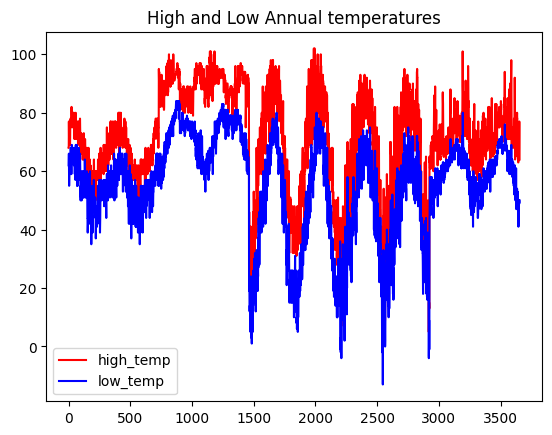

In [234]:
# First, select only the two columns you care about:
subset = df[['high_temp', 'low_temp']]

# plot them with colors
subset.plot(color=['red', 'blue'])

# if you want to set a title, you have to save the plot as a variable ("ax" is common) and then apply a title, like this:

ax = subset.plot(color=['red', 'blue'])
ax.set_title("High and Low Annual temperatures")

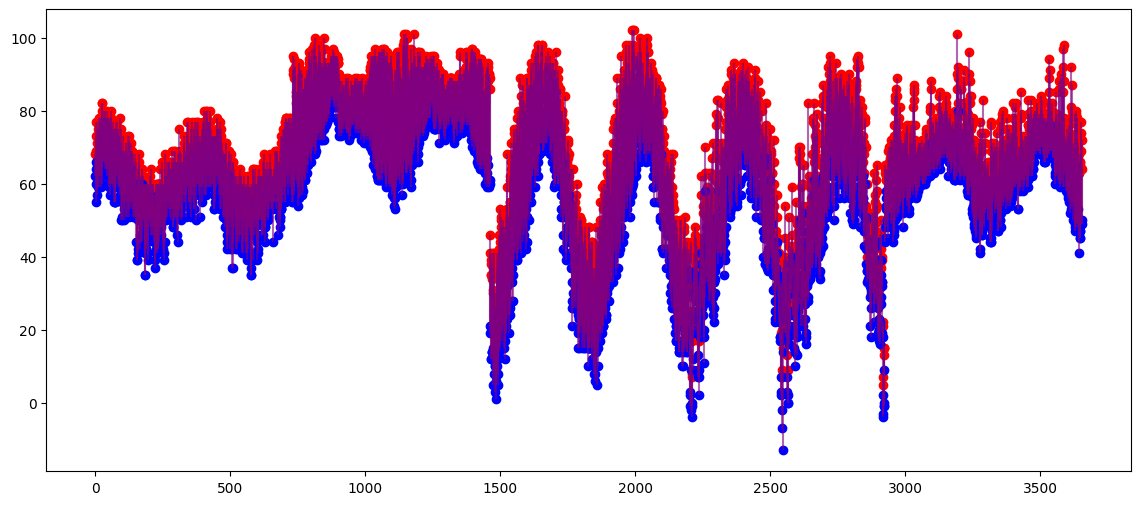

In [235]:
# Let's instead try a "range" or "lolipop" plot where we plot the *distance* between the low and high temp for each row
# For more sophisticated plots like this we need matplotlib, we can simply pass the series directly to matplot library:
import matplotlib.pyplot as plt

# Plot the points (as before) with red and blue:
x = df.index # these are the row numbers!

# Set the figure size to widen it:
plt.figure(figsize = (14, 6))

plt.scatter(x, df['high_temp'], color='red', label='High Temp')
plt.scatter(x, df['low_temp'], color='blue', label='Low Temp')

# Next draw vertical lines between the points with `plt.vlines(x, y1, y2)`
plt.vlines(x, df['low_temp'], df['high_temp'], color='purple', alpha=0.6)


10. Make a new column of made up data to add to the weather dataframe. Let's call it "predicted_weather"
Using the values from the "events" column, let us randomly select values and put them in our new column. (You will not be making up data but you do need to know how to take a Series or array and "paste" it into an existing dataframe.

In [240]:
df.events.unique() # note some are lists...

array(['Rain', nan, 'Fog , Rain , Thunderstorm', 'Fog , Rain',
       'Rain , Thunderstorm', 'Rain , Hail', 'Fog', 'Thunderstorm',
       'Rain , Hail , Thunderstorm', 'Snow', 'Rain , Snow',
       'Fog , Thunderstorm', 'Fog , Snow', 'Fog , Rain , Snow',
       'Fog , Snow , Thunderstorm'], dtype=object)

In [241]:
# save a list variable returning some single events from the "events" column
unique_weather = ["Rain","Fog", "Hail", "Snow", "Thunderstorm"]

In [242]:
# use numpy's `random.choice()` function to randomly select from your variable. 
import numpy as np
newcoldata = np.random.choice(unique_weather, size = len(df))

# add the newcoldata as a new column of data into your existing dataframe:
df['predicted_weather'] = newcoldata

11. Make a cross-tabulation (confusion matrix) for categorical variables using the `pd.crosstab()` function. Let us look at where our "events" matches our "predicted weather"

In [247]:
# replace my variables with the appropriate column names to compute the cross tabulation
pd.crosstab(df['events'], df['predicted_weather'])

predicted_weather,Fog,Hail,Rain,Snow,Thunderstorm
events,,,,,
Fog,16,19,25,30,25
"Fog , Rain",7,10,9,7,11
"Fog , Rain , Snow",2,1,1,1,0
"Fog , Rain , Thunderstorm",0,2,3,3,2
"Fog , Snow",2,4,3,1,2
"Fog , Snow , Thunderstorm",0,0,0,1,0
"Fog , Thunderstorm",0,1,0,0,0
Rain,173,169,180,199,189
"Rain , Hail",1,0,2,2,2
